In [211]:
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pprint import pprint
  
# fetch dataset 
secondary_mushroom_dataset = fetch_ucirepo(id=848) 
  
# data (as pandas dataframes) 
x = secondary_mushroom_dataset.data.features 
y = secondary_mushroom_dataset.data.targets.iloc[:,0]
df = x
df["label"] = y.map({'e': 0, 'p': 1})
# metadata 
pprint(secondary_mushroom_dataset.metadata) 

{'abstract': 'Dataset of simulated mushrooms for binary classification into '
             'edible and poisonous.',
 'additional_info': {'citation': None,
                     'funded_by': None,
                     'instances_represent': None,
                     'preprocessing_description': None,
                     'purpose': 'Inspired by the Mushroom Data Set of J. '
                                'Schlimmer: '
                                'url:https://archive.ics.uci.edu/ml/datasets/Mushroom.',
                     'recommended_data_splits': None,
                     'sensitive_data': None,
                     'summary': 'The given information is about the Secondary '
                                'Mushroom Dataset, the Primary Mushroom '
                                'Dataset used for the simulation and the '
                                'respective metadata can be found in the zip.\n'
                                '\n'
                                'This datas

In [212]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cap-diameter          61069 non-null  float64
 1   cap-shape             61069 non-null  str    
 2   cap-surface           46949 non-null  str    
 3   cap-color             61069 non-null  str    
 4   does-bruise-or-bleed  61069 non-null  str    
 5   gill-attachment       51185 non-null  str    
 6   gill-spacing          36006 non-null  str    
 7   gill-color            61069 non-null  str    
 8   stem-height           61069 non-null  float64
 9   stem-width            61069 non-null  float64
 10  stem-root             9531 non-null   str    
 11  stem-surface          22945 non-null  str    
 12  stem-color            61069 non-null  str    
 13  veil-type             3177 non-null   str    
 14  veil-color            7413 non-null   str    
 15  has-ring              61069 no

## EDA

In [213]:
import matplotlib.ticker as mtick

def bar_plot(df, column):
    """ Create a bar plot

    """

    df = df[["label", column]].pivot_table(
    columns="label",
    aggfunc="size",
    index=column
    )
    ax = df.apply(lambda x: x / x.sum(), axis=1).plot(kind='bar', stacked=True)
    plt.title(f"Mushroom Edibility by {column}")

    for i, label_col in enumerate(df.columns):
        # Get raw counts for this specific label category
        raw_values = df[label_col].values
        
        # Format labels (leave blank if the count is 0 so it doesn't crowd the chart)
        labels = [f'{int(val)}' if val > 0 else '' for val in raw_values]
        
        # Draw the labels inside the bar segments
        ax.bar_label(ax.containers[i], labels=labels, label_type='center', color='black', fontweight='bold')

    # 4. Format the Y-axis as percentages and finalize layout
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.xlabel(column)
    plt.ylabel("Proportion")
    plt.xticks(rotation=0)  # Keeps X-axis text readable

    plt.tight_layout()


    label_baseline = (y.value_counts() / y.value_counts().sum()).iloc[1]
    
    plt.axhline(y=label_baseline, color='gray', linestyle='--', label="Dataset Average (Edible)")
    plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')

    
    plt.show()

# CAP SHAPES B and O seem to influence class - more often poisonous than edible


now plotting cap-diameter vs label...


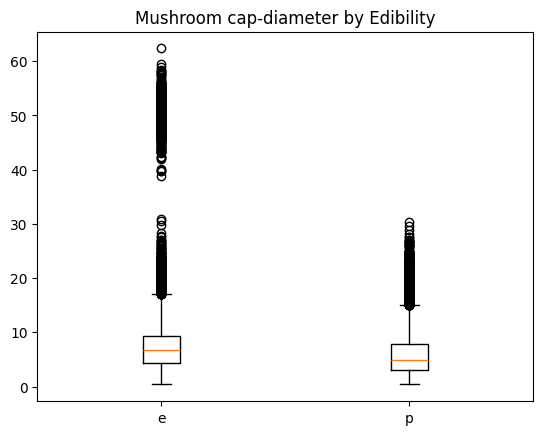

now plotting cap-shape vs label...


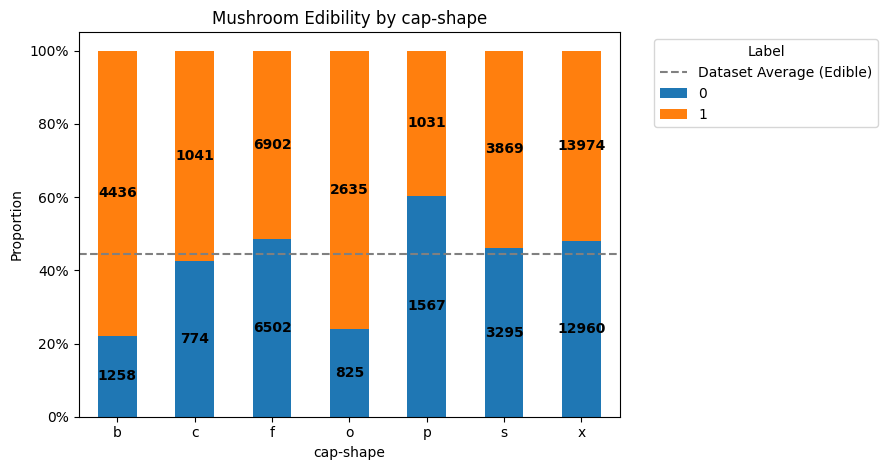

now plotting cap-surface vs label...


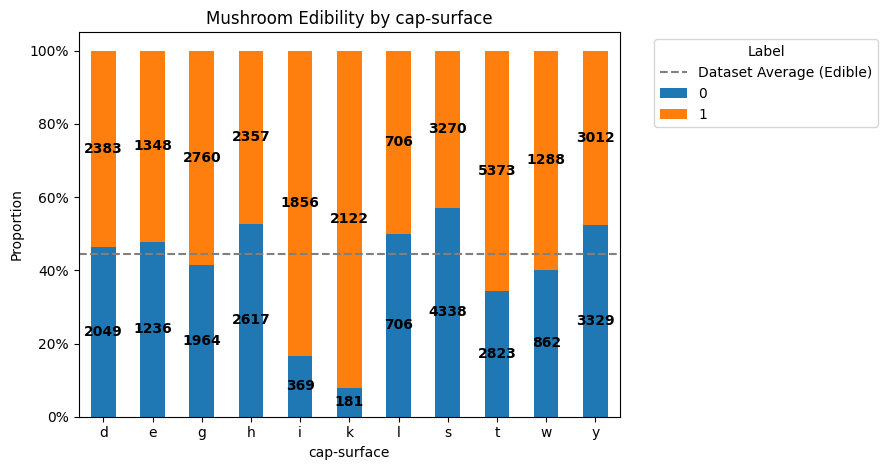

now plotting cap-color vs label...


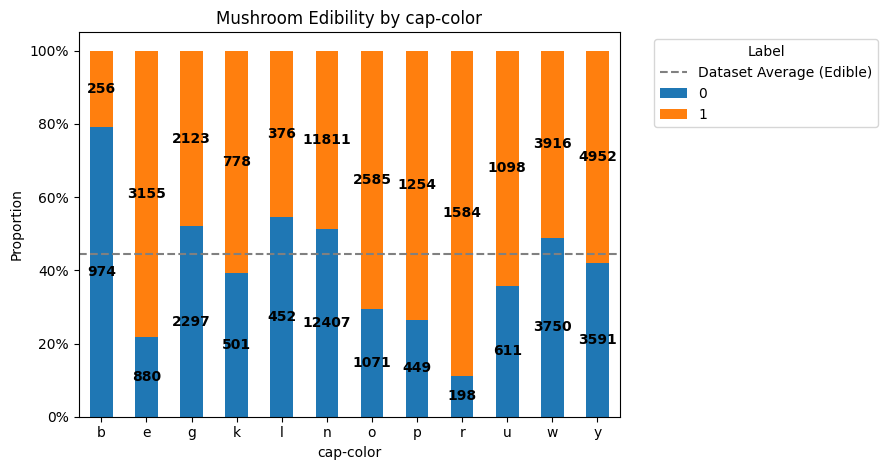

now plotting does-bruise-or-bleed vs label...


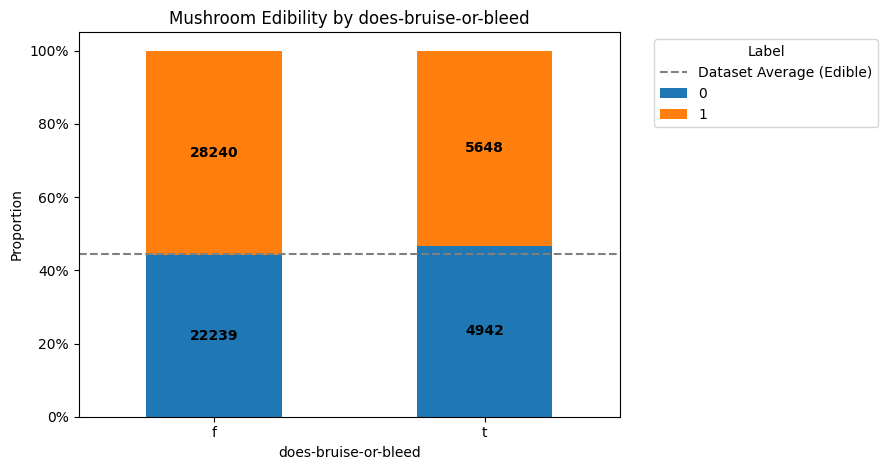

now plotting gill-attachment vs label...


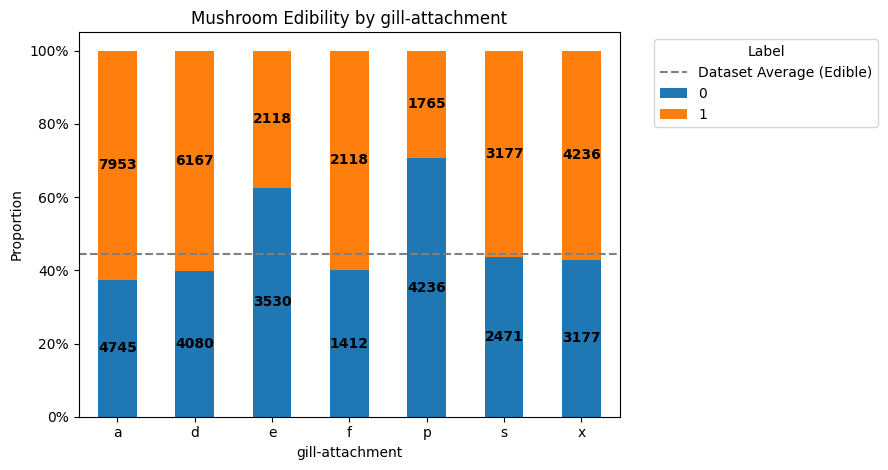

now plotting gill-spacing vs label...


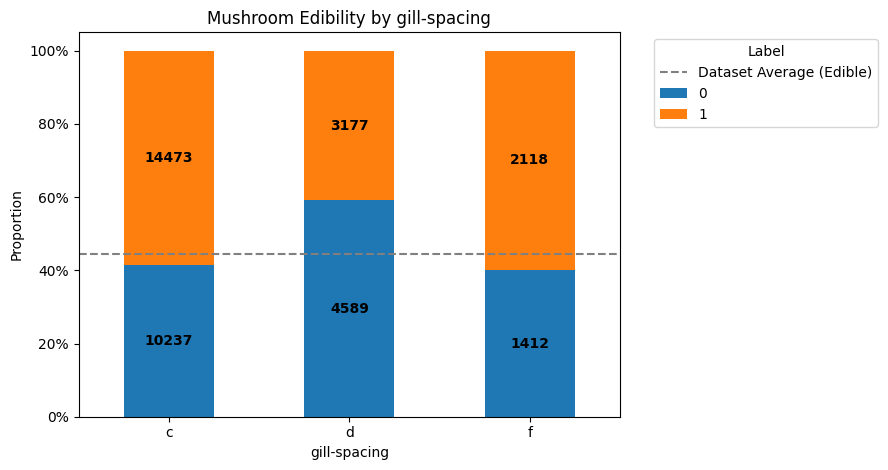

now plotting gill-color vs label...


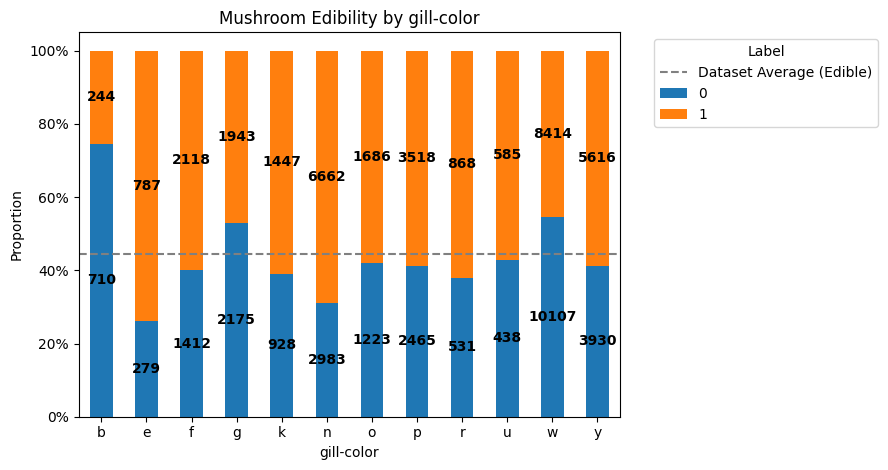

now plotting stem-height vs label...


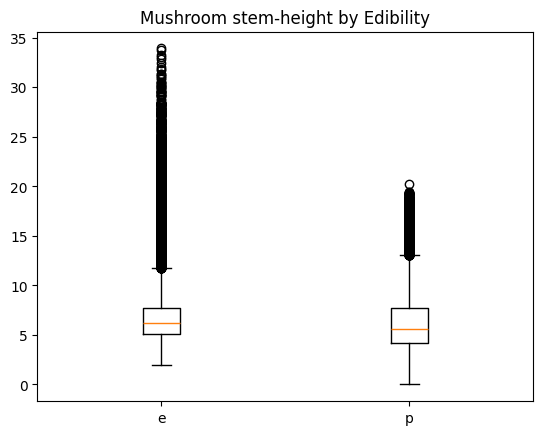

now plotting stem-width vs label...


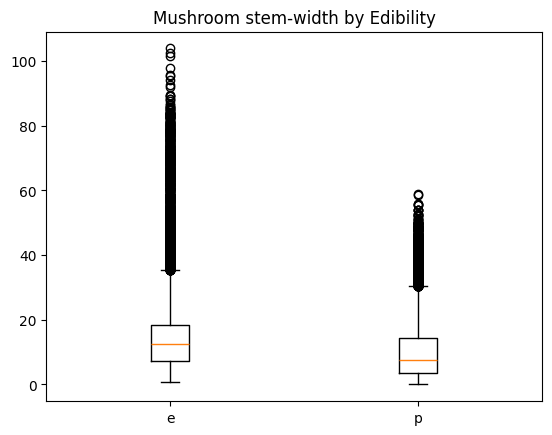

now plotting stem-root vs label...


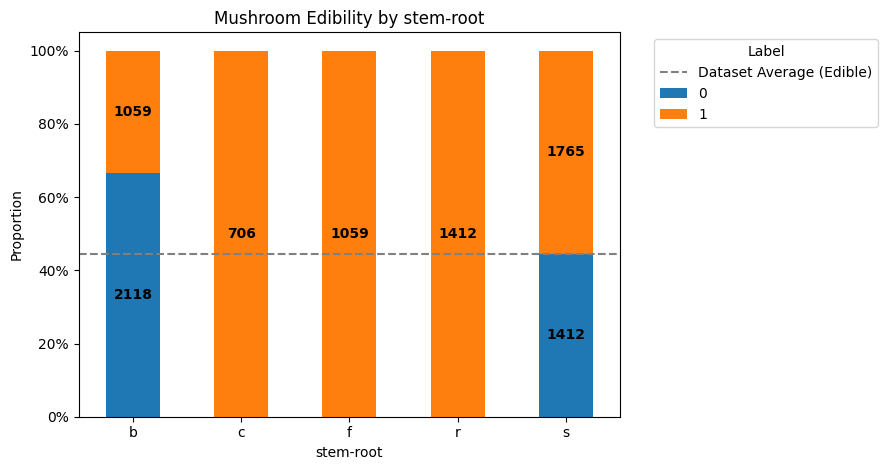

now plotting stem-surface vs label...


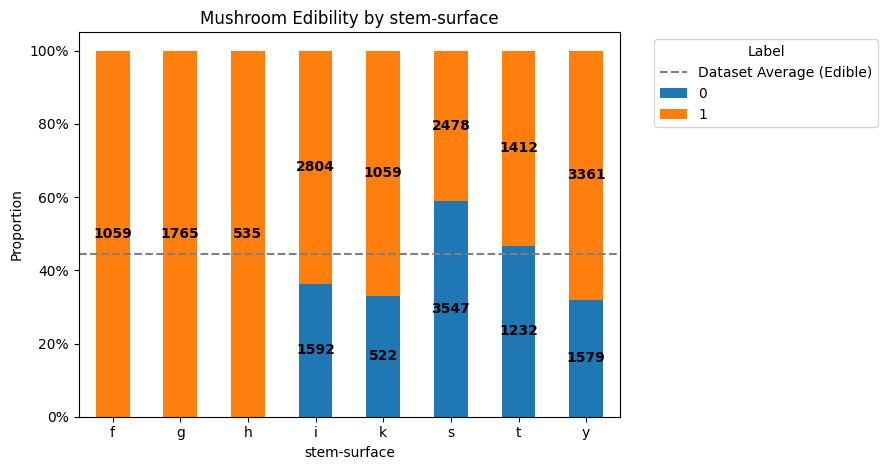

now plotting stem-color vs label...


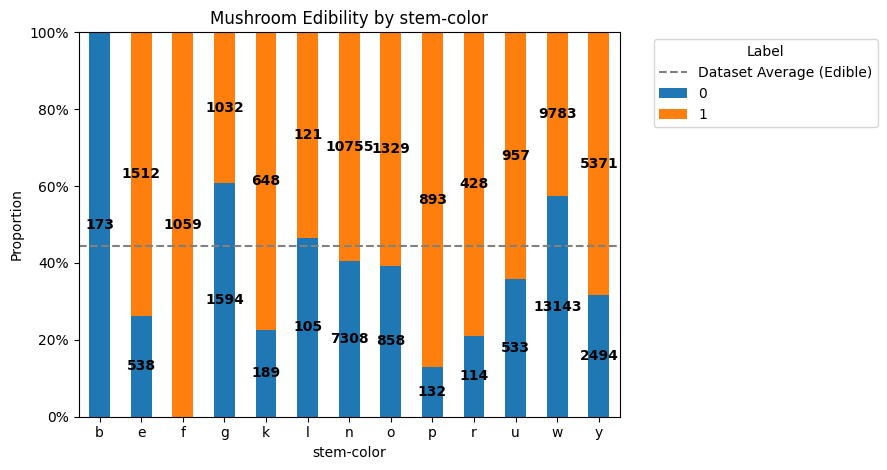

now plotting veil-type vs label...


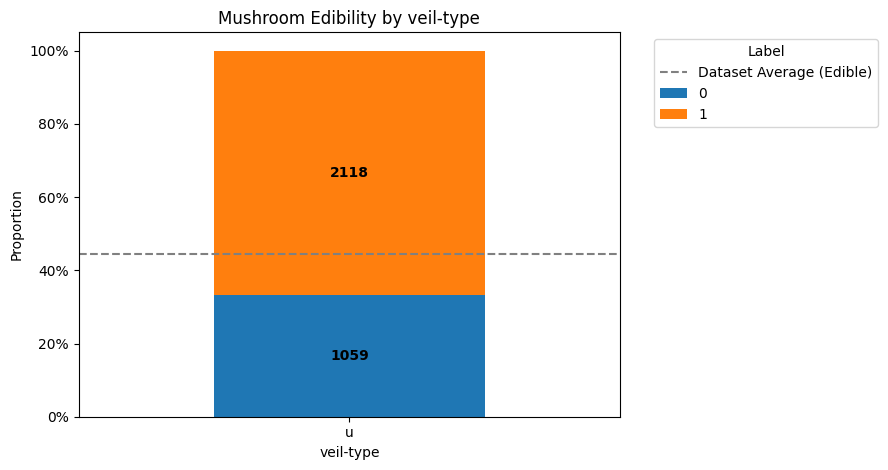

now plotting veil-color vs label...


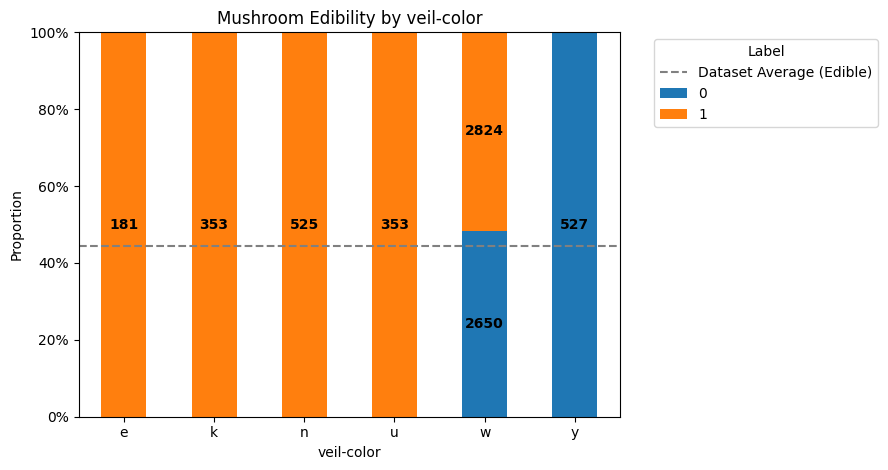

now plotting has-ring vs label...


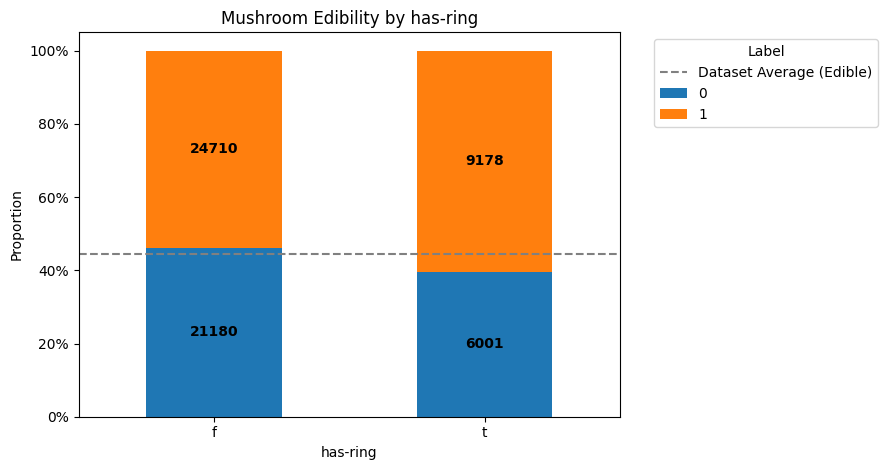

now plotting ring-type vs label...


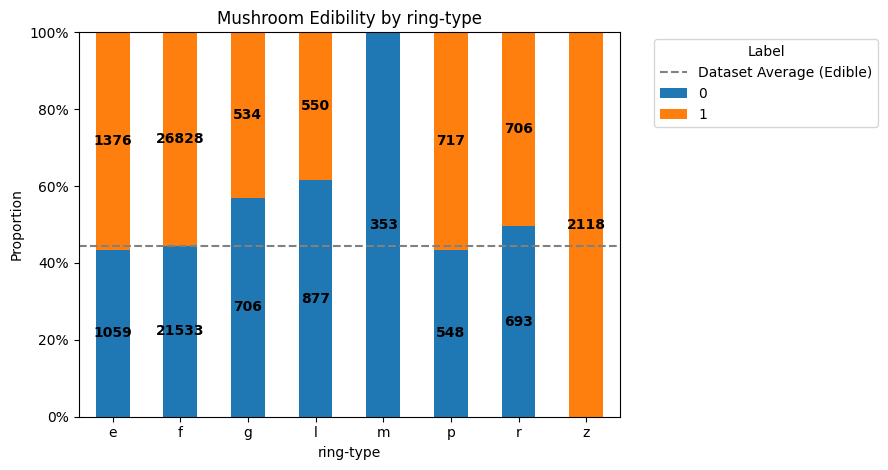

now plotting spore-print-color vs label...


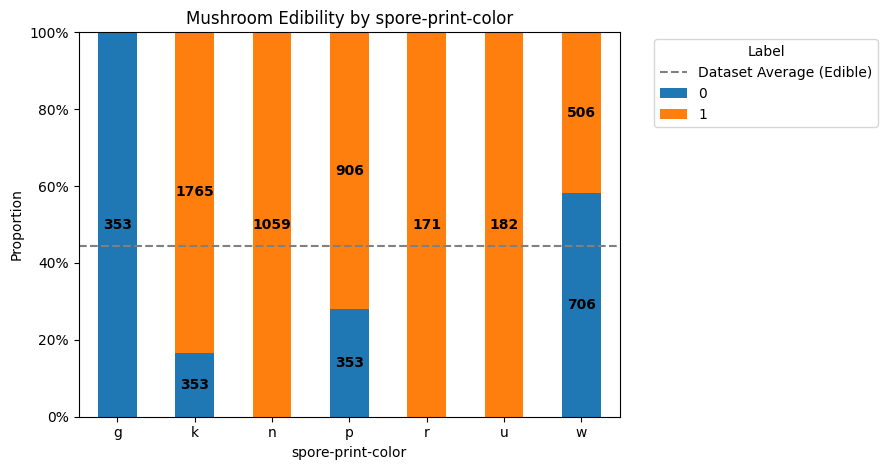

now plotting habitat vs label...


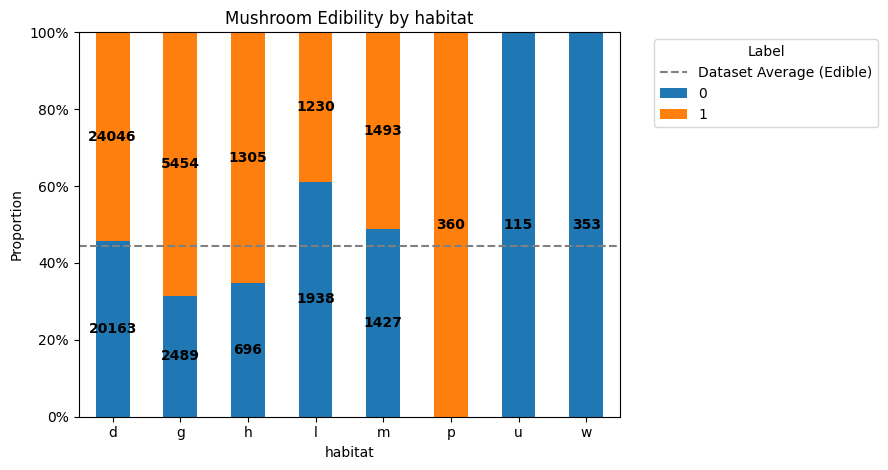

now plotting season vs label...


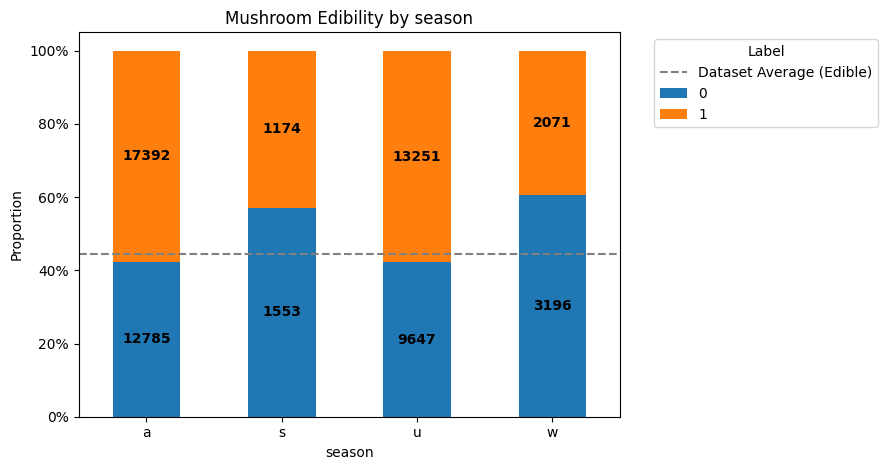

In [214]:
for col in df.columns[:-1]:
    print(f"now plotting {col} vs label...")
    if col not in ["cap-diameter", "stem-width", "stem-height"]:
        bar_plot(df, col)
    else:
        grouped_data = [x[col][y == val] for val in unique_y]
        plt.boxplot(grouped_data, tick_labels=unique_y)
        plt.title(f"Mushroom {col} by Edibility")
        plt.show()

In [215]:
print(df.columns)

Index(['cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-height', 'stem-width', 'stem-root', 'stem-surface', 'stem-color',
       'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color',
       'habitat', 'season', 'label'],
      dtype='str')


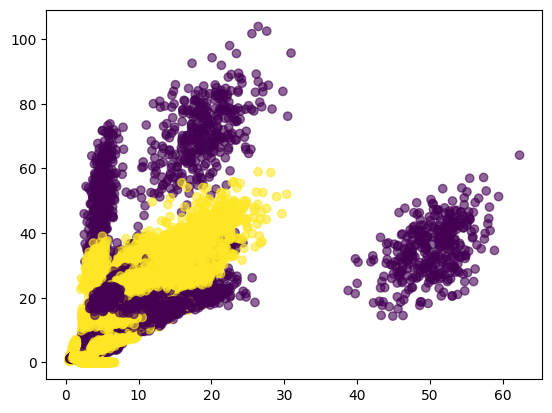

In [216]:
cat_codes = pd.Series(y).astype('category').cat.codes
plt.scatter(df["cap-diameter"], df["stem-width"], c=cat_codes, alpha=0.6)

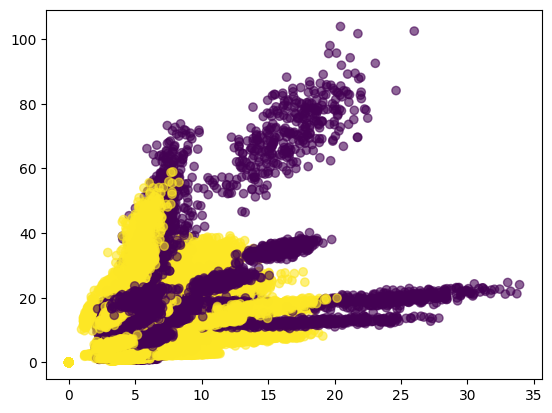

In [217]:
plt.scatter(df["stem-height"], df["stem-width"], c=cat_codes, alpha=0.6)

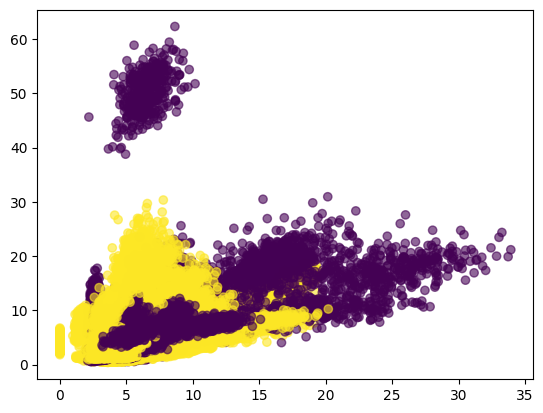

In [218]:
plt.scatter(df["stem-height"], df["cap-diameter"], c=cat_codes, alpha=0.6)

## Dataset 1: Impute NAs with "Missing"

In [219]:
df_with_missing = df.copy()

missing_columns = ["cap-surface", "gill-attachment", "gill-spacing", "stem-root", "stem-surface", "veil-type", "veil-color", "ring-type", "spore-print-color"]
df_with_missing[missing_columns] = df_with_missing[missing_columns].fillna("Missing")

In [220]:
cat_columns = df_with_missing.columns[[(type(col) == str) for col in df_with_missing.loc[0]]]
df_with_missing = df_with_missing.astype({col:"category" for col in cat_columns})

In [221]:
print(cat_columns)

Index(['cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed',
       'gill-attachment', 'gill-spacing', 'gill-color', 'stem-root',
       'stem-surface', 'stem-color', 'veil-type', 'veil-color', 'has-ring',
       'ring-type', 'spore-print-color', 'habitat', 'season'],
      dtype='str')


In [222]:
df_with_missing.head()

,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,...,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season,label
0,15.26,x,g,o,f,e,Missing,w,16.95,17.09,...,y,w,u,w,t,g,Missing,d,w,1
1,16.60,x,g,o,f,e,Missing,w,17.99,18.19,...,y,w,u,w,t,g,Missing,d,u,1
2,14.07,x,g,o,f,e,Missing,w,17.80,17.74,...,y,w,u,w,t,g,Missing,d,w,1
3,14.17,f,h,e,f,e,Missing,w,15.77,15.98,...,y,w,u,w,t,p,Missing,d,w,1
4,14.64,x,h,o,f,e,Missing,w,16.53,17.20,...,y,w,u,w,t,p,Missing,d,w,1


In [223]:
df_with_missing.to_csv("df_all_rows")

## Dataset 2: One-hot encoded with missing variable included

In [224]:
df_encoded = pd.get_dummies(df, columns=cat_columns, dummy_na=True, drop_first=True)

In [225]:
df_encoded.columns

Index(['cap-diameter', 'stem-height', 'stem-width', 'label', 'cap-shape_c',
       'cap-shape_f', 'cap-shape_o', 'cap-shape_p', 'cap-shape_s',
       'cap-shape_x',
       ...
       'habitat_l', 'habitat_m', 'habitat_p', 'habitat_u', 'habitat_w',
       'habitat_nan', 'season_s', 'season_u', 'season_w', 'season_nan'],
      dtype='str', length=120)

In [226]:
df_encoded.shape

(61069, 120)

In [227]:
# Sum your one-hot columns to see how many '1's are in each
column_counts = df_encoded.sum()
print(column_counts)
# Look for columns that only trigger a few times out of 60,000 rows
rare_columns = column_counts[column_counts < 20].index.to_list()
print(rare_columns)

df_encoded = df_encoded.drop(columns=rare_columns)

cap-diameter    411229.76
stem-height     401927.96
stem-width      741952.32
label            33888.00
cap-shape_c       1815.00
                  ...    
habitat_nan          0.00
season_s          2727.00
season_u         22898.00
season_w          5267.00
season_nan           0.00
Length: 120, dtype: float64
['cap-shape_nan', 'cap-color_nan', 'does-bruise-or-bleed_nan', 'gill-color_nan', 'stem-color_nan', 'has-ring_nan', 'habitat_nan', 'season_nan']


## Dataset 3: One-hot encoded with imputation and missing flags

In [228]:
import pandas as pd

# Step 1: Define your column groups based on your analysis
extreme_missing_cols = ['spore-print-color', 'stem-root', 'veil-type', 'veil-color']
medium_missing_cols  = ['stem-surface', 'cap-surface', 'gill-spacing']
low_missing_cols     = ['gill-attachment', 'ring-type']

# Step 2: Handle Extreme Missingness
df_encoded_imputed = df.copy()
df_encoded_imputed[extreme_missing_cols] = df_encoded_imputed[extreme_missing_cols].fillna('Missing')

# Step 3: Handle Medium Missingness (Flag + Impute)
for col in medium_missing_cols:
    df_encoded_imputed[f'{col}_was_missing'] = df[col].isna().astype(int) # Create the 1/0 flag
    col_mode = df_encoded_imputed[col].mode()[0]
    df_encoded_imputed[col] = df_encoded_imputed[col].fillna(col_mode)                    # Fill original with Mode

# Step 4: Handle Low Missingness (Direct Impute)
for col in low_missing_cols:
    col_mode = df_encoded_imputed[col].mode()[0]
    df_encoded_imputed[col] = df_encoded_imputed[col].fillna(col_mode)

# Step 5: NOW it is perfectly safe to One-Hot Encode!
# Every single NaN has been resolved systematically.
df_encoded_imputed = pd.get_dummies(df_encoded_imputed, columns=cat_columns, drop_first=True)

In [229]:
df_encoded_imputed.head()

,cap-diameter,stem-height,stem-width,label,stem-surface_was_missing,cap-surface_was_missing,gill-spacing_was_missing,cap-shape_c,cap-shape_f,cap-shape_o,...,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_s,season_u,season_w
0,15.26,16.95,17.09,1,0,0,1,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,16.60,17.99,18.19,1,0,0,1,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,14.07,17.80,17.74,1,0,0,1,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,14.17,15.77,15.98,1,0,0,1,False,True,False,...,False,False,False,False,False,False,False,False,False,True
4,14.64,16.53,17.20,1,0,0,1,False,False,False,...,False,False,False,False,False,False,False,False,False,True


## Preprocessing Steps

### PCA

- use `df`
- imputer using KNN
- scale with StandardScaler

### NN

- use `df_with_missing`
- no imputation (use entity embedding layer)
- scale with MinMaxScaler

### Tree-based methods

- use `df_with_missing`
- Ordinal encoding of categories
- no scaling needed

### Regression with LASSO

- use `df_encoded` or `df_encoded_imputed`
- scale with StandardScaler

## Regression + Regularization (LASSO)

In [230]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

X_imputed = df_encoded_imputed
X_raw = df_encoded

# 1. ALWAYS split into Train and Test sets first!
X_train_imputed, X_test_imputed, y_train_imputed, y_test_imputed = train_test_split(X_imputed, y, test_size=0.2, random_state=42)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y, test_size=0.2, random_state=42)

# 2. Initialize the StandardScaler
scaler = StandardScaler()

numeric_cols = X_raw.select_dtypes(include=['float64', 'int64']).columns.tolist()

X_train_imputed = X_train_imputed.copy()
X_test_imputed = X_test_imputed.copy()

X_train_raw = X_train_raw.copy()
X_test_raw = X_test_raw.copy()

# 3. FIT and TRANSFORM the training data
# This calculates the mean and variance of the training set, then scales it.
X_train_imputed[numeric_cols] = scaler.fit_transform(X_train_imputed[numeric_cols])

# 4. TRANSFORM the test data
# CRITICAL: We ONLY transform. We use the training set's mean/variance to scale the test set.
X_test_imputed[numeric_cols] = scaler.transform(X_test_imputed[numeric_cols])

X_train_raw[numeric_cols] = scaler.fit_transform(X_train_raw[numeric_cols])

# 4. TRANSFORM the test data
# CRITICAL: We ONLY transform. We use the training set's mean/variance to scale the test set.
X_test_raw[numeric_cols] = scaler.transform(X_test_raw[numeric_cols])

In [231]:
X_train_raw.head()

,cap-diameter,stem-height,stem-width,label,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,...,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_s,season_u,season_w
42308,-0.813292,-0.906761,-0.138059,-1.113704,False,False,False,False,False,True,...,True,False,False,False,False,False,False,False,True,False
39798,-0.397978,-0.043783,-0.486727,0.897905,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
40487,0.185757,-0.141984,-0.379445,0.897905,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
27727,0.036474,0.250820,-0.243355,0.897905,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
25153,1.852752,0.063345,1.020196,-1.113704,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [232]:
X_train_raw["label"] = y_train_raw
X_test_raw["label"] = y_test_raw

X_train_imputed["label"] = y_train_imputed
X_test_imputed["label"] = y_test_imputed

In [233]:
X_train_imputed.head()

,cap-diameter,stem-height,stem-width,label,stem-surface_was_missing,cap-surface_was_missing,gill-spacing_was_missing,cap-shape_c,cap-shape_f,cap-shape_o,...,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_s,season_u,season_w
42308,-0.813292,-0.906761,-0.138059,e,1,0,0,False,False,False,...,True,False,False,False,False,False,False,False,True,False
39798,-0.397978,-0.043783,-0.486727,p,1,0,0,True,False,False,...,False,False,False,False,False,False,False,False,True,False
40487,0.185757,-0.141984,-0.379445,p,0,0,1,False,False,False,...,False,False,False,False,False,False,False,False,False,True
27727,0.036474,0.250820,-0.243355,p,1,0,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
25153,1.852752,0.063345,1.020196,e,1,0,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Tree-based Methods

In [234]:
from sklearn.preprocessing import OrdinalEncoder

X_tree = df_with_missing.drop(columns="label")

# 1. ALWAYS split into Train and Test sets first!
X_train_tree, X_test_tree, y_train, y_test = train_test_split(X_tree, y, test_size=0.2, random_state=4)

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_final_tree = X_train_tree.copy()
X_test_final_tree = X_test_tree.copy()

X_train_final_tree[cat_columns] = encoder.fit_transform(X_train_tree[cat_columns])
X_test_final_tree[cat_columns] = encoder.transform(X_test_tree[cat_columns])

In [235]:
X_train_final_tree.head()

,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
7292,2.93,6.0,8.0,10.0,0.0,2.0,1.0,10.0,3.26,7.77,0.0,0.0,11.0,0.0,0.0,0.0,2.0,0.0,1.0,2.0
13637,1.65,6.0,3.0,11.0,0.0,2.0,2.0,5.0,2.14,2.35,0.0,6.0,6.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0
37356,3.47,6.0,9.0,4.0,0.0,6.0,1.0,9.0,5.13,6.22,0.0,8.0,11.0,0.0,0.0,1.0,1.0,6.0,1.0,2.0
24146,8.65,2.0,0.0,1.0,0.0,7.0,1.0,10.0,6.72,16.96,0.0,6.0,11.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0
49086,7.24,6.0,1.0,11.0,1.0,5.0,0.0,8.0,5.82,11.92,0.0,0.0,12.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0


In [236]:
X_train_final_tree["label"] = y_train
X_test_final_tree["label"] = y_test

## NN

In [237]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

X_NN = df_with_missing.drop(columns="label")

# 1. ALWAYS split into Train and Test sets first!
X_train, X_test, y_train, y_test = train_test_split(X_NN, y, test_size=0.2, random_state=4)

# 2. Initialize the StandardScaler
scaler = MinMaxScaler()

numeric_cols = X_final.select_dtypes(include=['float64', 'int64']).columns.tolist()

X_train_scaled_NN = X_train.copy()
X_test_scaled_NN = X_test.copy()

# 3. FIT and TRANSFORM the training data
# This calculates the mean and variance of the training set, then scales it.
X_train_scaled_NN[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# 4. TRANSFORM the test data
# CRITICAL: We ONLY transform. We use the training set's mean/variance to scale the test set.
X_test_scaled_NN[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [238]:
X_train_scaled_NN.head()

,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
7292,0.041156,x,s,w,f,d,c,w,0.096108,0.074776,Missing,Missing,w,Missing,Missing,f,f,Missing,g,u
13637,0.020497,x,g,y,f,d,d,n,0.063090,0.022616,Missing,s,n,Missing,Missing,f,f,Missing,h,a
37356,0.049871,x,t,l,f,s,c,u,0.151238,0.059859,Missing,y,w,Missing,Missing,t,e,u,g,u
24146,0.133473,f,Missing,e,f,x,c,w,0.198113,0.163218,Missing,s,w,Missing,Missing,f,f,Missing,d,u
49086,0.110717,x,d,y,t,p,Missing,r,0.171580,0.114715,Missing,Missing,y,Missing,Missing,f,f,Missing,d,a


In [239]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_final_NN = X_train_scaled_NN.copy()
X_test_final_NN = X_test_scaled_NN.copy()

X_train_final_NN[cat_columns] = encoder.fit_transform(X_train_scaled_NN[cat_columns])
X_test_final_NN[cat_columns] = encoder.transform(X_test_scaled_NN[cat_columns])
# Calculate the vocabulary size (number of unique categories + 1 for safety)
num_unique_categories = len(encoder.categories_[0])

In [240]:
num_unique_categories

7

In [241]:
X_train_final_NN.head()

,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
7292,0.041156,6.0,8.0,10.0,0.0,2.0,1.0,10.0,0.096108,0.074776,0.0,0.0,11.0,0.0,0.0,0.0,2.0,0.0,1.0,2.0
13637,0.020497,6.0,3.0,11.0,0.0,2.0,2.0,5.0,0.063090,0.022616,0.0,6.0,6.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0
37356,0.049871,6.0,9.0,4.0,0.0,6.0,1.0,9.0,0.151238,0.059859,0.0,8.0,11.0,0.0,0.0,1.0,1.0,6.0,1.0,2.0
24146,0.133473,2.0,0.0,1.0,0.0,7.0,1.0,10.0,0.198113,0.163218,0.0,6.0,11.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0
49086,0.110717,6.0,1.0,11.0,1.0,5.0,0.0,8.0,0.171580,0.114715,0.0,0.0,12.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0


In [242]:
X_train_final_NN["label"] = y_train
X_test_final_NN["label"] = y_test

## PCA

In [243]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder

X = df.drop(columns="label")

categorical_cols = X.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

# 1. Map text categories to integers, leaving NaNs intact
# handle_unknown='use_encoded_value' ensures new test categories don't break the code
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value', 
    unknown_value=np.nan
)

X_encoded = X.copy()
X_encoded[categorical_cols] = encoder.fit_transform(X[categorical_cols])

# 2. Apply KNN Imputer
# n_neighbors=5 is standard. It looks at the closest 5 rows to guess the missing category.
imputer = KNNImputer(n_neighbors=5)
X_imputed_array = imputer.fit_transform(X_encoded)

# Convert the resulting numpy array back into a pandas DataFrame
X_imputed = pd.DataFrame(X_imputed_array, columns=X_encoded.columns)

# 3. CRITICAL STEP: Round the imputed values
# KNN averages the neighbors' values, which can result in decimals (like 1.4).
# We must round to the nearest whole integer so it maps cleanly back to a real category.
X_imputed[categorical_cols] = np.round(X_imputed[categorical_cols])

# 4. Convert the integers back into their original text strings
X_final = X_imputed.copy()
X_final[categorical_cols] = encoder.inverse_transform(X_imputed[categorical_cols])
X_final.head()

,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,15.26,x,g,o,f,e,c,w,16.95,17.09,s,y,w,u,w,t,g,n,d,w
1,16.60,x,g,o,f,e,c,w,17.99,18.19,s,y,w,u,w,t,g,n,d,u
2,14.07,x,g,o,f,e,c,w,17.80,17.74,s,y,w,u,w,t,g,n,d,w
3,14.17,f,h,e,f,e,c,w,15.77,15.98,s,y,w,u,w,t,p,r,d,w
4,14.64,x,h,o,f,e,c,w,16.53,17.20,s,y,w,u,w,t,p,n,d,w


In [244]:
X_final.columns

Index(['cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-height', 'stem-width', 'stem-root', 'stem-surface', 'stem-color',
       'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color',
       'habitat', 'season'],
      dtype='str')

In [245]:
df.columns

Index(['cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-height', 'stem-width', 'stem-root', 'stem-surface', 'stem-color',
       'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color',
       'habitat', 'season', 'label'],
      dtype='str')

In [246]:
X_pca = X_final.copy()
X_pca = pd.get_dummies(X_pca, columns=cat_columns, drop_first=True)

In [247]:
column_counts = X_pca.sum()

# Look for columns that only trigger a few times out of 60,000 rows
rare_columns = column_counts[column_counts < 50]
print(rare_columns)


Series([], dtype: float64)


In [248]:
X_pca.head()

,cap-diameter,stem-height,stem-width,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,cap-surface_e,...,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_s,season_u,season_w
0,15.26,16.95,17.09,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
1,16.60,17.99,18.19,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,14.07,17.80,17.74,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
3,14.17,15.77,15.98,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,14.64,16.53,17.20,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True


In [249]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. ALWAYS split into Train and Test sets first!
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# 2. Initialize the StandardScaler
scaler = StandardScaler()

numeric_cols = X_final.select_dtypes(include=['float64', 'int64']).columns.tolist()

X_train_scaled_pca = X_train.copy()
X_test_scaled_pca = X_test.copy()

# 3. FIT and TRANSFORM the training data
# This calculates the mean and variance of the training set, then scales it.
X_train_scaled_pca[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# 4. TRANSFORM the test data
# CRITICAL: We ONLY transform. We use the training set's mean/variance to scale the test set.
X_test_scaled_pca[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [250]:
X_train_scaled_pca.head()

,cap-diameter,stem-height,stem-width,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,cap-surface_e,...,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_s,season_u,season_w
42308,-0.813292,-0.906761,-0.138059,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,True,False
39798,-0.397978,-0.043783,-0.486727,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
40487,0.185757,-0.141984,-0.379445,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
27727,0.036474,0.250820,-0.243355,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
25153,1.852752,0.063345,1.020196,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [251]:
X_train_scaled_pca["label"] = y_train
X_test_scaled_pca["label"] = y_test



In [252]:
X_train_scaled_pca.head()

,cap-diameter,stem-height,stem-width,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,cap-surface_e,...,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_s,season_u,season_w,label
42308,-0.813292,-0.906761,-0.138059,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,e
39798,-0.397978,-0.043783,-0.486727,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,p
40487,0.185757,-0.141984,-0.379445,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,p
27727,0.036474,0.250820,-0.243355,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,p
25153,1.852752,0.063345,1.020196,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,e


In [253]:
X_test_scaled_pca.head()

,cap-diameter,stem-height,stem-width,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,cap-surface_e,...,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_s,season_u,season_w,label
11541,-1.033389,-0.644892,-1.079762,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,e
35700,-0.441998,-0.713335,-0.590037,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,p
55781,0.480496,-0.618110,0.857285,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,e
29303,-0.681234,-1.025793,-0.649638,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,p
46601,-0.575970,-0.216379,-0.559243,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,e


In [254]:
X_train_scaled_pca.to_csv("train_PCA.csv")
X_test_scaled_pca.to_csv("test_PCA.csv")

X_train_final_NN.to_csv("train_NN.csv")
X_test_final_NN.to_csv("test_NN.csv")

X_train_final_tree.to_csv("train_Tree.csv")
X_test_final_tree.to_csv("test_Tree.csv")

X_train_raw.to_csv("train_Regression_raw.csv")
X_test_raw.to_csv("test_Regression_raw.csv")

X_train_imputed.to_csv("train_Regression_imputed.csv")
X_test_imputed.to_csv("test_Regression_imputed.csv")